In [3]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

In [ ]:
ROOT = Path('/Users/jinyecai/Desktop/ML_Mortgage')
LAYOUT_XLSX = ROOT / "file_layout.xlsx"   
OUTDIR = ROOT / "processed_mortgage"
# OUTDIR.mkdir(parents=True, exist_ok=True)
YEARS = list(range(2016, 2026))

def normalize_col(s: str) -> str:
    s = str(s).strip()
    s = s.replace("%", "pct").replace("&", "and").replace("/", "_").replace("-", "_")
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", "_", s.lower()).strip("_")
    s = re.sub(r"_+", "_", s)
    return s

def load_perf_columns(layout_xlsx: Path):
    xls = pd.ExcelFile(layout_xlsx)
    df = pd.read_excel(xls, sheet_name="Monthly Performance Data File")
    df = df.copy()
    df.columns = [f"c{i}" for i in range(df.shape[1])]
    pos_col = df.columns[0]
    name_col = df.columns[1]

    df = df[pd.to_numeric(df[pos_col], errors="coerce").notna()].copy()
    df["position"] = df[pos_col].astype(int)
    df["attr_name"] = df[name_col].astype(str).str.strip()

    cols = [normalize_col(x) for x in df.sort_values("position")["attr_name"].tolist()]
    return cols

perf_cols = load_perf_columns(LAYOUT_XLSX)

def read_pipe_txt_noheader(txt_path: Path, expected_cols: list, file_year=None):
    df = pd.read_csv(
        txt_path,
        sep="|",
        header=None,
        dtype="string",
        na_filter=False,
        engine="python"
    )
    # drop trailing empty column(s)
    while df.shape[1] > 0:
        last_col = df.iloc[:, -1]
        if (last_col == "").all():
            df = df.iloc[:, :-1]
        else:
            break

    df.columns = expected_cols
    if file_year is not None:
        df["file_year"] = int(file_year)
    return df

perf_list = []
for y in YEARS:
    f = ROOT / f"sample_{y}" / f"sample_svcg_{y}.txt"
    dfp = read_pipe_txt_noheader(f, perf_cols, file_year=y)
    perf_list.append(dfp)

perf_df = pd.concat(perf_list, ignore_index=True)
print("perf_df shape:", perf_df.shape)

In [2]:
# cleaning dates
def yyyymm_to_int(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.where(s.str.fullmatch(r"\d{6}"), pd.NA)
    return pd.to_numeric(s, errors="coerce").astype("Int64")

perf_df["rp_yyyymm"] = yyyymm_to_int(perf_df["monthly_reporting_period"])
perf_df["zb_yyyymm"] = yyyymm_to_int(perf_df["zero_balance_effective_date"])

# ZBC use two digits
perf_df["zbc"] = perf_df["zero_balance_code"].astype("string").str.strip()
perf_df.loc[perf_df["zbc"].isin(["", "<NA>"]), "zbc"] = pd.NA
perf_df["zbc"] = perf_df["zbc"].where(perf_df["zbc"].isna(), perf_df["zbc"].str.zfill(2))

# delinquency status：digits + RA
perf_df["dlq"] = perf_df["current_loan_delinquency_status"].astype("string").str.strip()
perf_df.loc[perf_df["dlq"].isin(["", "<NA>"]), "dlq"] = pd.NA
perf_df["dlq_num"] = pd.to_numeric(perf_df["dlq"], errors="coerce")  # RA becomes NaN

In [3]:
PREPAY_ZBC = {"01"}

OTHER_ZBC = {"02","03","09","15","16","96"}

# row-level flags
is_default = (perf_df["dlq_num"].notna() & (perf_df["dlq_num"] >= 3))

is_prepay = perf_df["zbc"].isin(PREPAY_ZBC)
is_other  = perf_df["zbc"].isin(OTHER_ZBC)

# For ZBC events, use zero_balance_effective_date，otherwise fallback to reporting period
perf_df["zbc_event_yyyymm"] = perf_df["zb_yyyymm"].fillna(perf_df["rp_yyyymm"])

perf_df["is_default"] = is_default.astype(int)
perf_df["is_prepay"]  = is_prepay.astype(int)
perf_df["is_other"]   = is_other.astype(int)

# loan-level first event months
# default uses rp_yyyymm；prepay/other uses zbc_event_yyyymm
loan = perf_df["loan_sequence_number"]

tD = perf_df.loc[perf_df["is_default"]==1].groupby(loan)["rp_yyyymm"].min()
tP = perf_df.loc[perf_df["is_prepay"]==1].groupby(loan)["zbc_event_yyyymm"].min()
tO = perf_df.loc[perf_df["is_other"] ==1].groupby(loan)["zbc_event_yyyymm"].min()
t_end = perf_df.groupby(loan)["rp_yyyymm"].max()

events = pd.DataFrame({"tD": tD, "tP": tP, "tO": tO, "t_end": t_end}).reset_index()
events.rename(columns={"loan_sequence_number":"loan_id"}, inplace=True)

In [6]:
events

,loan_id,tD,tP,tO,t_end
0,F16Q10000006,<NA>,201806,<NA>,201806
1,F16Q10000027,202006,<NA>,<NA>,202509
2,F16Q10000048,<NA>,202006,<NA>,202006
3,F16Q10000054,<NA>,202006,<NA>,202006
4,F16Q10000076,<NA>,202311,<NA>,202311
...,...,...,...,...,...
487495,F25Q30236409,<NA>,<NA>,<NA>,202509
487496,F25Q30236424,<NA>,<NA>,<NA>,202509
487497,F25Q30236485,<NA>,<NA>,<NA>,202509
487498,F25Q30236495,<NA>,<NA>,<NA>,202509


In [7]:
# get t* and event_type，with priority：default(0) < prepay(1) < other(2) < censor(3)
def pick_event(row):
    candidates = []
    if pd.notna(row["tD"]): candidates.append((int(row["tD"]), 0, "default"))
    if pd.notna(row["tP"]): candidates.append((int(row["tP"]), 1, "prepay"))
    if pd.notna(row["tO"]): candidates.append((int(row["tO"]), 2, "other"))
    if pd.notna(row["t_end"]): candidates.append((int(row["t_end"]), 3, "censor"))
    month, _, etype = min(candidates)  # tuple, compare from the first element
    return pd.Series({"t_star": month, "event_type": etype})

events[["t_star","event_type"]] = events.apply(pick_event, axis=1)
events

,loan_id,tD,tP,tO,t_end,t_star,event_type
0,F16Q10000006,<NA>,201806,<NA>,201806,201806,prepay
1,F16Q10000027,202006,<NA>,<NA>,202509,202006,default
2,F16Q10000048,<NA>,202006,<NA>,202006,202006,prepay
3,F16Q10000054,<NA>,202006,<NA>,202006,202006,prepay
4,F16Q10000076,<NA>,202311,<NA>,202311,202311,prepay
...,...,...,...,...,...,...,...
487495,F25Q30236409,<NA>,<NA>,<NA>,202509,202509,censor
487496,F25Q30236424,<NA>,<NA>,<NA>,202509,202509,censor
487497,F25Q30236485,<NA>,<NA>,<NA>,202509,202509,censor
487498,F25Q30236495,<NA>,<NA>,<NA>,202509,202509,censor


In [9]:
# join back to panel
perf2 = perf_df.merge(
    events[["loan_id","t_star","event_type"]],
    left_on="loan_sequence_number",
    right_on="loan_id",
    how="left"
)

# risk set censoring：keep t <= t*
perf2 = perf2.loc[perf2["rp_yyyymm"].notna()].copy()
perf2 = perf2.loc[perf2["rp_yyyymm"] <= perf2["t_star"]].copy()

# labels：only when t* month and event_type matches
perf2["y_default"] = ((perf2["rp_yyyymm"] == perf2["t_star"]) & (perf2["event_type"]=="default")).astype(int)
perf2["y_prepay"]  = ((perf2["rp_yyyymm"] == perf2["t_star"]) & (perf2["event_type"]=="prepay")).astype(int)

# export data
default_out = OUTDIR / "perf_performance_labeled_for_default_2016_2025.parquet"
prepay_out  = OUTDIR / "perf_performance_labeled_for_prepay_2016_2025.parquet"
# both_out    = OUTDIR / "perf_panel_labeled_both_2016_2025.parquet"

# perf2.to_parquet(both_out, index=False)
perf2.drop(columns=["y_prepay"]).to_parquet(default_out, index=False)
perf2.drop(columns=["y_default"]).to_parquet(prepay_out, index=False)

print("saved:", default_out, prepay_out)
#sanity check
print("share of default events:", perf2["y_default"].mean(), "share of prepay events:", perf2["y_prepay"].mean())

saved: /Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage/perf_performance_labeled_for_default_2016_2025.parquet /Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage/perf_performance_labeled_for_prepay_2016_2025.parquet
share of default events: 0.0008598215140321249 share of prepay events: 0.010655129730395887


In [4]:
# part two, read in data, and get two modeling dataset, prepay and default, merge with origination separately
pd.set_option('display.max_colwidth', 10)

OUTDIR = Path("processed_mortgage")
perf_pd = OUTDIR / "perf_performance_labeled_for_default_2016_2025.parquet"
pd_df = pd.read_parquet(perf_pd)
pd_df.shape

(17875803, 46)

In [ ]:
# merge with origination and then export panel: default and prepay
from pathlib import Path
import pandas as pd

OUTDIR = Path("processed_mortgage")

default_out = OUTDIR / "perf_performance_labeled_for_default_2016_2025.parquet"
prepay_out  = OUTDIR / "perf_performance_labeled_for_prepay_2016_2025.parquet"
orig_out    = OUTDIR / "orig_only_2016_2025.parquet"

keep_cols = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "rp_yyyymm",
    "file_year",
    "loan_id",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "current_actual_upb",
    "interest_bearing_upb",
    "current_interest_rate",
    "estimated_loan_to_value_eltv",
    "modification_flag",
]

# 1) read orig + ensure unique key
orig = pd.read_parquet(orig_out)

# origination data drop duplicate loans
orig = orig.sort_values(["file_year"]).drop_duplicates(subset=["loan_sequence_number"], keep="last")

# 2) default panel
dfD = pd.read_parquet(default_out, columns=keep_cols + ["y_default"])
panelD = dfD.merge(orig, on="loan_sequence_number", how="left", validate="m:1")

# 3) prepay panel
dfP = pd.read_parquet(prepay_out, columns=keep_cols + ["y_prepay"]) 
panelP = dfP.merge(orig, on="loan_sequence_number", how="left", validate="m:1")

# 4) export
panelD_out = OUTDIR / "panel_default_modeling_2016_2025.parquet"
panelP_out = OUTDIR / "panel_prepay_modeling_2016_2025.parquet"
panelD.to_parquet(panelD_out, index=False)
panelP.to_parquet(panelP_out, index=False)

print("saved:", panelD_out, panelP_out)
print("rows default before/after merge:", len(dfD), len(panelD))
print("rows prepay  before/after merge:", len(dfP), len(panelP))

In [6]:
# Additional Analysis based on newly created data

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("/Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage")

panelD_path = OUTDIR / "panel_default_modeling_2016_2025.parquet"
panelP_path = OUTDIR / "panel_prepay_modeling_2016_2025.parquet"

dfD = pd.read_parquet(panelD_path)
dfP = pd.read_parquet(panelP_path)

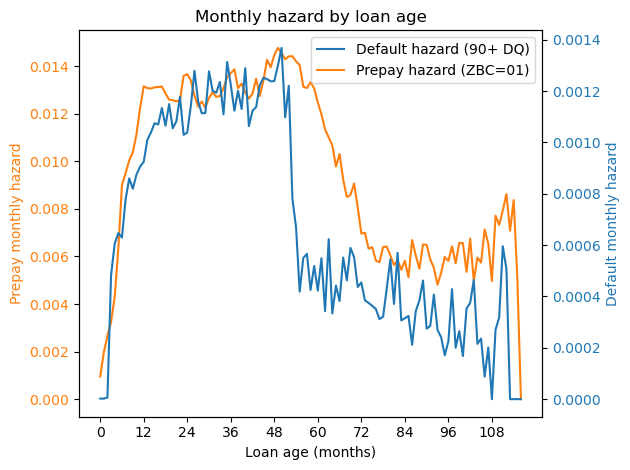

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# hazD: columns [loan_age, y_default]
# hazP: columns [loan_age, y_prepay]
hazD = dfD.groupby("loan_age")["y_default"].mean().reset_index()
hazP = dfP.groupby("loan_age")["y_prepay"].mean().reset_index()

# align loan_age
x = hazD["loan_age"].astype(int).values
yD = hazD["y_default"].values
yP = hazP.set_index("loan_age")["y_prepay"].reindex(hazD["loan_age"]).values

fig, ax1 = plt.subplots()

# left：Prepay
l1, = ax1.plot(x, yP, color="tab:orange", label="Prepay hazard (ZBC=01)")
ax1.set_xlabel("Loan age (months)")
ax1.set_ylabel("Prepay monthly hazard", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:orange")

# x-axis ticks: every 12 months
tick_step = 12
ax1.set_xticks(np.arange(x.min(), x.max() + 1, tick_step))

# right axis: Default（blue）
ax2 = ax1.twinx()
l2, = ax2.plot(x, yD, color="tab:blue", label="Default hazard (90+ DQ)")
ax2.set_ylabel("Default monthly hazard", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("Monthly hazard by loan age")

# merge legend
ax1.legend([l2, l1], [l2.get_label(), l1.get_label()], loc="upper right")

plt.tight_layout()
plt.show()